# Lorenz-63: ETKF

## 1. Overview

This tutorial applies the ensemble transform Kalman filter (ETKF) to the
chaotic Lorenz-63 model with fully observed, noisy observations. It follows
`docs/notebook_spec.md`; the paired CLI script is
`examples/scripts/l63_etkf.py`.

## 2. Model

The Lorenz-63 model is the three-variable chaotic system

$$
\dot{x} = \sigma (y - x), \qquad
\dot{y} = x (r - z) - y, \qquad
\dot{z} = x y - b z,
$$

with the standard chaotic parameters $\sigma = 10$, $r = 28$, $b = 8/3$
(`da.l63.lorenz63`). The state is $x_n = (x, y, z) \in \mathbb{R}^{3}$.
The discrete forecast map $M$ integrates the system with fourth-order
Runge-Kutta (`da.scheme.rk4`) using time step $\delta t$ over one
assimilation window of $n_{\mathrm{obs}}$ steps, i.e.
$\Delta t = n_{\mathrm{obs}}\, \delta t$:

$$
x_n = M(x_{n-1}) = \Psi_{\delta t}^{n_{\mathrm{obs}}}(x_{n-1}).
$$

## 3. Observation

The full state is observed with additive Gaussian noise every assimilation
window:

$$
y_n = H x_n + \varepsilon_n, \qquad
H = I_3, \qquad
\varepsilon_n \sim N(0, R), \quad R = r_0^2 I_3 .
$$

The observation-noise scale used for RMSE comparison is
$\sigma_{\mathrm{obs}} = \sqrt{\operatorname{tr}(R)/N_y} = r_0$
(see `docs/notebook_spec.md`).

## 4. DA method

The **ensemble transform Kalman filter (ETKF)** represents the forecast
uncertainty by an ensemble $X^f \in \mathbb{R}^{m \times N_x}$ with mean
$\bar{x}^f$ and anomaly matrix $A^f$ (rows $x^{f,(i)} - \bar{x}^f$).

**Forecast step:** each member is propagated by the model,
$x_n^{f,(i)} = M(x_{n-1}^{a,(i)})$.

**Analysis step:** with $\tilde{P} = \big[(m-1) I + (H A^f)^{\mathsf T}
R^{-1} (H A^f)\big]^{-1}$,

$$
\bar{x}^a = \bar{x}^f + A^f\, \tilde{P}\, (H A^f)^{\mathsf T} R^{-1}
\,(y - H \bar{x}^f),
\qquad
A^a = A^f \big[(m-1)\, \tilde{P}\big]^{1/2}.
$$

Multiplicative inflation is applied to the anomalies, $A \to \alpha A$
(covariance inflation $\alpha^2$), to compensate for sampling error.

## 5. Parameters

| Parameter | Symbol | Value |
| --- | --- | --- |
| integration step | $\delta t$ | 0.01 |
| steps per window | $n_{\mathrm{obs}}$ | 5 |
| assimilation cycles | | 400 |
| observation noise variance | $r_0^2$ | 2.0 |
| ensemble size | $m$ | 12 |
| multiplicative inflation | $\alpha$ | 1.02 |
| initial ensemble | | attractor sample |
| random seed | | 7 |

The script exposes `--cycles`, `--ensemble-size`, `--obs-noise-variance`,
`--inflation`, `--dt`, `--obs-interval`, and `--seed`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from da.l63 import lorenz63
from da.scheme import rk4
from da.etkf import ETKF

def l63_step(x, dt):
    return rk4(lorenz63, 0.0, np.asarray(x), (), dt)


def advance(x, dt, n_steps):
    x = np.asarray(x, dtype=float).copy()
    for _ in range(n_steps):
        x = l63_step(x, dt)
    return x


def rmse(x, truth):
    return float(np.sqrt(np.mean((np.asarray(x) - np.asarray(truth)) ** 2)))


def attractor_ensemble(rng, base, size, spinup=2000, interval=25, pool=1000):
    """Climatological sample from the attractor (cf. examples/scripts/_common.py)."""
    x = advance(base, dt, spinup)
    members = np.empty((pool, np.size(base)))
    for i in range(pool):
        x = advance(x, dt, interval)
        members[i] = x
    return members[rng.choice(pool, size=size, replace=False)]

dt, obs_interval, cycles, seed = 0.01, 5, 400, 7
m, alpha = 12, 1.02
H = np.eye(3)
R = 2.0 * np.eye(3)

## 6. Truth and observations

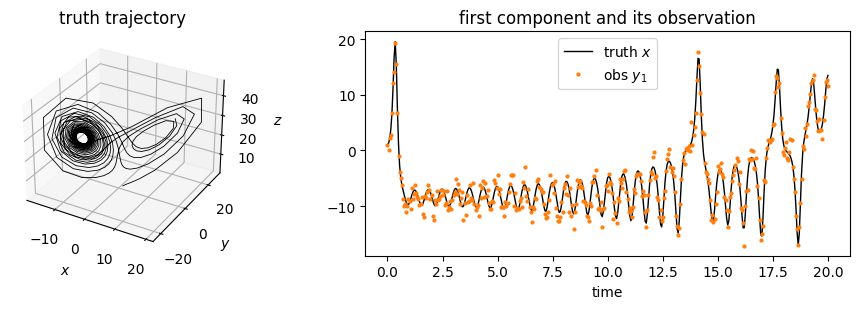

In [2]:
rng = np.random.default_rng(seed)
x = np.array([1.0, 1.0, 1.0])
truth = [x.copy()]
obs = [H @ x + rng.multivariate_normal(np.zeros(3), R)]
for _ in range(cycles):
    x = advance(x, dt, obs_interval)
    truth.append(x.copy())
    obs.append(H @ x + rng.multivariate_normal(np.zeros(3), R))
truth, obs = np.asarray(truth), np.asarray(obs)
t = np.arange(cycles + 1) * dt * obs_interval

fig = plt.figure(figsize=(10, 3.2))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot(*truth.T, lw=0.6, color="k")
ax.set_title("truth trajectory")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax = fig.add_subplot(1, 2, 2)
ax.plot(t, truth[:, 0], color="k", lw=1, label="truth $x$")
ax.plot(t, obs[:, 0], ".", color="tab:orange", ms=4, label="obs $y_1$")
ax.set_xlabel("time")
ax.legend()
ax.set_title("first component and its observation")
fig.tight_layout()

## 7. Assimilation results

The initial ensemble is drawn from the model attractor (a climatological
sample), so its mean starts an attractor-scale distance from the truth. Each
cycle forecasts every member over one window and assimilates the new
observation.

In [3]:
X0 = attractor_ensemble(rng, np.array([1.0, 1.0, 1.0]), m)
filt = ETKF(l63_step, H, R, alpha=alpha)
filt.initialize(X0)

means = [filt.X.mean(axis=0)]
rmses = [rmse(means[0], truth[0])]
for k in range(1, cycles + 1):
    for _ in range(obs_interval):
        filt.forecast(dt)
    filt.update(obs[k])
    means.append(filt.X.mean(axis=0))
    rmses.append(rmse(means[-1], truth[k]))
means, rmses = np.asarray(means), np.asarray(rmses)

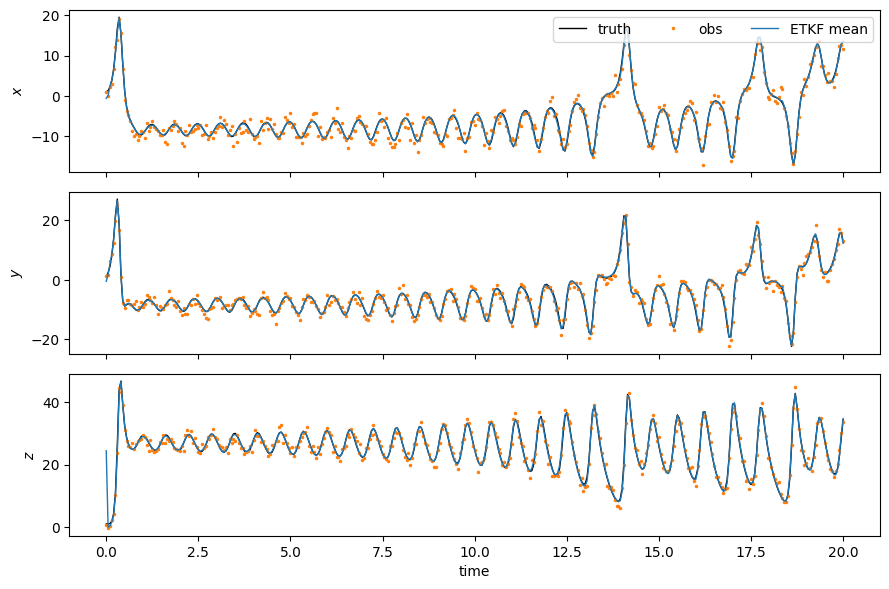

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, truth[:, i], color="k", lw=1, label="truth")
    ax.plot(t, obs[:, i], ".", color="tab:orange", ms=3, label="obs")
    ax.plot(t, means[:, i], color="tab:blue", lw=1, label="ETKF mean")
    ax.set_ylabel(["$x$", "$y$", "$z$"][i])
axes[0].legend(ncol=3, loc="upper right")
axes[-1].set_xlabel("time")
fig.tight_layout()

## 8. RMSE

Analysis RMSE of the ensemble mean against the observation-noise scale
$\sigma_{\mathrm{obs}} = \sqrt{2}$.

observation noise scale: 1.414
mean RMSE (2nd half): 0.300


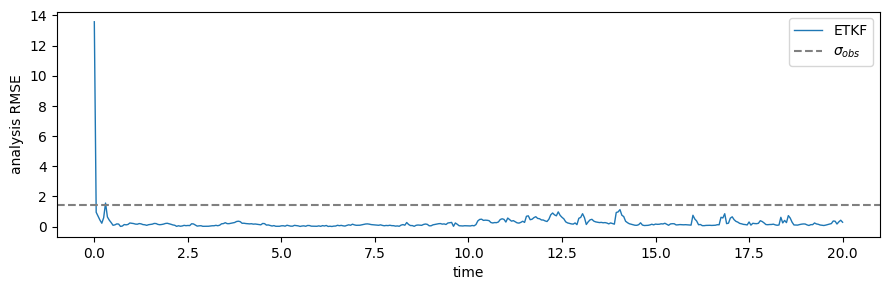

In [5]:
sigma_obs = np.sqrt(np.trace(R) / R.shape[0])
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, rmses, color="tab:blue", lw=1, label="ETKF")
ax.axhline(sigma_obs, color="gray", ls="--", label=r"$\sigma_{obs}$")
ax.set_xlabel("time")
ax.set_ylabel("analysis RMSE")
ax.legend()
fig.tight_layout()

half = cycles // 2
print(f"observation noise scale: {sigma_obs:.3f}")
print(f"mean RMSE (2nd half): {rmses[half:].mean():.3f}")

## 9. Summary

With $m = 12$ members and mild inflation $\alpha = 1.02$, the ETKF analysis
RMSE settles around $0.3$, clearly below
$\sigma_{\mathrm{obs}} \approx 1.41$: the flow-dependent ensemble
covariance extracts substantially more information from the observations
than the static or linearized covariances of 3DVar/ExKF.